# 实验 09 : 手写数字聚类与可视化 (K-Means + t-SNE)

## 1. 实验目标
1. 理解 K-Means 与 t-SNE 的配合使用。
2. **(新增)** 直观查看每个聚类簇内部的图片形态。
3. **(新增)** 能够通过“多数投票”机制，将无监督聚类结果转化为分类预测。

## 2. 实验环境
- Python 3.10
- Scikit-learn, NumPy, Matplotlib, Seaborn
---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from scipy.stats import mode
import os

%matplotlib inline
print("环境加载成功！")

环境加载成功！


## 3. 数据准备与模型训练 

In [ ]:
# 1. 加载数据
data_path = r'../data' # 确保这里是你的数据路径
if not os.path.exists(data_path):
    os.makedirs(data_path)

mnist = fetch_openml('mnist_784', version=1, data_home=data_path, as_frame=False, parser='auto')
X = mnist.data / 255.0
y = mnist.target.astype(int)

# 2. 采样 3000 个
np.random.seed(42)
indices = np.random.choice(len(X), 3000, replace=False)
X_sample = X[indices]
y_sample = y[indices]

# 3. K-Means 训练
print("正在训练 K-Means...")
kmeans = KMeans(n_clusters=10, n_init=10, random_state=42)
kmeans.fit(X_sample)
labels = kmeans.labels_
print("训练完成！")

正在训练 K-Means...
训练完成！


## 4. 可视化功能一：簇内画廊 (Cluster Gallery)

K-Means 把数据分成了 10 堆。我们很好奇，**“第 0 堆”里到底都是些什么数字？** 是全是 1，还是 4 和 9 混在了一起？

下面的代码会把每个 Cluster 里对应的前 10 张图打印出来。

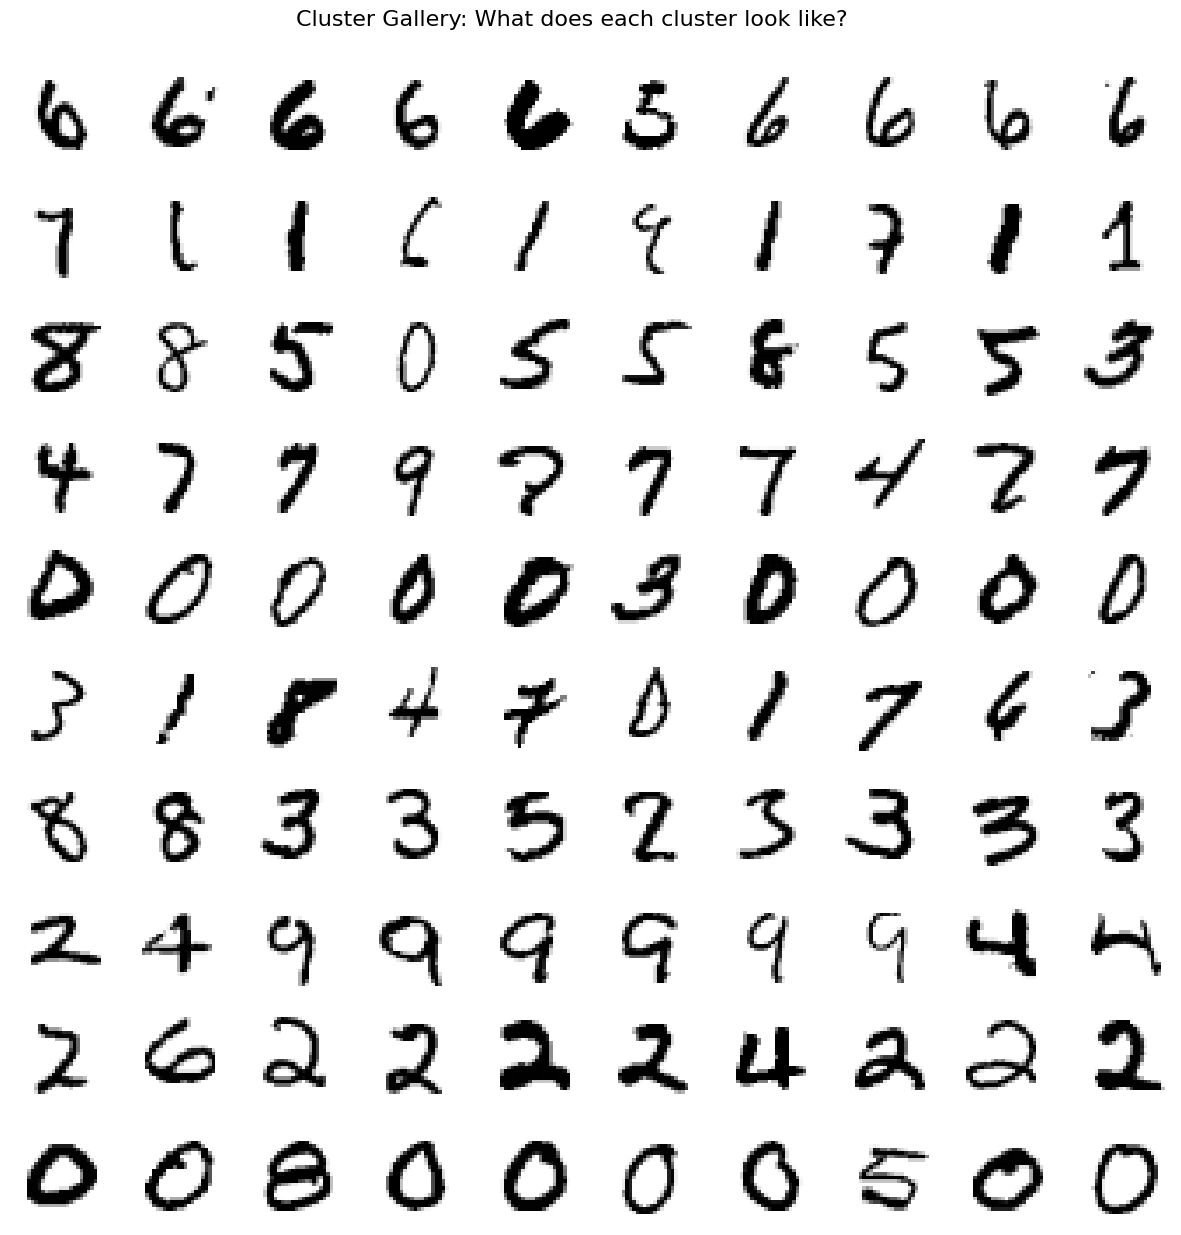

In [4]:
def plot_cluster_gallery(X, labels, n_clusters=10, n_samples_per_cluster=10):
    fig, axes = plt.subplots(n_clusters, n_samples_per_cluster, figsize=(15, 15))
    
    for i in range(n_clusters):
        # 找到属于当前簇 i 的所有样本索引
        cluster_indices = np.where(labels == i)[0]
        
        # 在当前行显示的标题 (显示该簇的数量)
        axes[i, 0].set_ylabel(f'Cluster {i}\n(Size: {len(cluster_indices)})', fontsize=12, rotation=0, labelpad=40)
        
        for j in range(n_samples_per_cluster):
            ax = axes[i, j]
            if j < len(cluster_indices):
                # 获取图片并 Reshape
                img = X[cluster_indices[j]].reshape(28, 28)
                ax.imshow(img, cmap='binary')
            ax.axis('off')
            
    plt.suptitle('Cluster Gallery: What does each cluster look like?', fontsize=16, y=0.92)
    plt.show()

plot_cluster_gallery(X_sample, labels)

## 5. 核心逻辑：给无名簇“贴标签” (Label Matching)

K-Means 是无监督的，它只知道“Cluster 0”，不知道那是数字“7”。
为了能展示“辨识结果”，我们需要做一个映射：

**规则**：如果 Cluster 0 里有 90% 的样本都是真实数字 "7"，那我们就把 Cluster 0 标记为 "7"。

In [5]:
def get_cluster_labels(y_true, cluster_labels):
    """创建一个映射表：Cluster ID -> 真实的数字 Label"""
    mapping = {}
    for i in range(10):
        # 找出 Cluster i 里所有的真实标签
        mask = (cluster_labels == i)
        if np.sum(mask) == 0:
            mapping[i] = -1 # 空簇
            continue
        
        # 找到出现次数最多的那个数字 (Mode)
        true_labels = y_true[mask]
        most_common = mode(true_labels, keepdims=True).mode[0]
        mapping[i] = most_common
        
    return mapping

# 获取映射字典
cluster_map = get_cluster_labels(y_sample, labels)

print("聚类映射结果:")
for cid, digit in cluster_map.items():
    print(f"Cluster {cid}  ==>  代表数字 {digit}")

聚类映射结果:
Cluster 0  ==>  代表数字 6
Cluster 1  ==>  代表数字 1
Cluster 2  ==>  代表数字 8
Cluster 3  ==>  代表数字 7
Cluster 4  ==>  代表数字 0
Cluster 5  ==>  代表数字 1
Cluster 6  ==>  代表数字 3
Cluster 7  ==>  代表数字 9
Cluster 8  ==>  代表数字 2
Cluster 9  ==>  代表数字 0


## 6. 可视化功能二：辨识结果演示 (Prediction Demo)

现在我们有了映射关系，可以像真正的分类器一样工作了！
随机抽取几张图，看看 K-Means 能不能认出它是几？

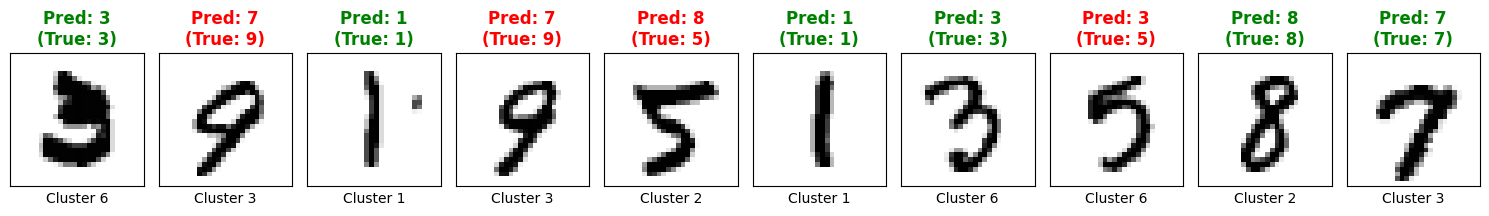

In [6]:
def show_predictions(X, y_true, labels, mapping, n_samples=10):
    plt.figure(figsize=(15, 3))
    
    # 随机选 n 个索引
    sample_indices = np.random.choice(len(X), n_samples, replace=False)
    
    for i, idx in enumerate(sample_indices):
        plt.subplot(1, n_samples, i+1)
        img = X[idx].reshape(28, 28)
        
        # 获取 K-Means 的预测
        cluster_id = labels[idx]
        predicted_digit = mapping[cluster_id]
        actual_digit = y_true[idx]
        
        # 绘图
        plt.imshow(img, cmap='binary')
        
        # 标题颜色：绿色表示对，红色表示错
        color = 'green' if predicted_digit == actual_digit else 'red'
        plt.title(f"Pred: {predicted_digit}\n(True: {actual_digit})", color=color, fontweight='bold')
        plt.xlabel(f"Cluster {cluster_id}")
        plt.xticks([]); plt.yticks([])
        
    plt.tight_layout()
    plt.show()

# 运行演示 (多运行几次可以看到不同的样本)
show_predictions(X_sample, y_sample, labels, cluster_map)

## 7. 拓展：查看“错得最离谱”的样本

有时候看错误样本比看正确样本更有趣。下面的代码专门挑出**预测错误的样本**展示。

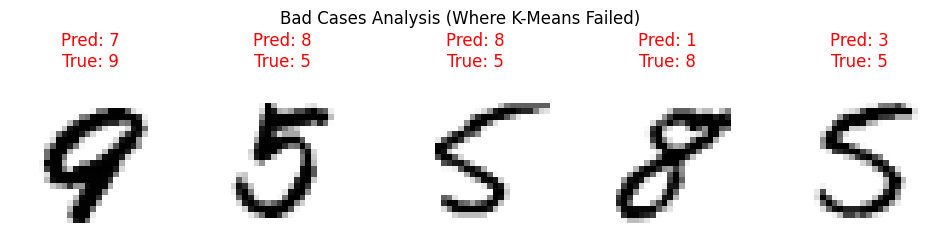

In [7]:
def show_errors(X, y_true, labels, mapping, n_samples=5):
    plt.figure(figsize=(12, 3))
    
    # 找出所有预测错误的索引
    error_indices = []
    for i in range(len(X)):
        if mapping[labels[i]] != y_true[i]:
            error_indices.append(i)
    
    if not error_indices:
        print("太强了，居然一个错的都没有！")
        return

    # 随机选几个错误的
    show_indices = np.random.choice(error_indices, min(n_samples, len(error_indices)), replace=False)
    
    for i, idx in enumerate(show_indices):
        plt.subplot(1, n_samples, i+1)
        img = X[idx].reshape(28, 28)
        
        cluster_id = labels[idx]
        pred = mapping[cluster_id]
        true_val = y_true[idx]
        
        plt.imshow(img, cmap='binary')
        plt.title(f"Pred: {pred}\nTrue: {true_val}", color='red')
        plt.axis('off')
        
    plt.suptitle("Bad Cases Analysis (Where K-Means Failed)")
    plt.show()

show_errors(X_sample, y_sample, labels, cluster_map)

## 8.1 K-Means 聚类

让机器自己把这 3000 张图分成 10 堆。

In [8]:
n_digits = 10
print(f"正在进行 K-Means 聚类 (K={n_digits})...")

kmeans = KMeans(n_clusters=n_digits, n_init=10, random_state=42)
# 注意：这里只传入了 X，没有传入 y
kmeans.fit(X_sample)

# 获取聚类结果标签 (Cluster ID: 0-9)
kmeans_labels = kmeans.labels_
print("聚类完成！")

正在进行 K-Means 聚类 (K=10)...
聚类完成！


## 8.2 第二步：t-SNE 降维可视化

现在我们有了 784 维的数据 `X_sample` 和聚类标签 `kmeans_labels`。
接下来使用 t-SNE 将数据压扁到 2 维，绘制出一张“手写数字地图”。

> **提示**：运行下面这段代码可能需要 10-30 秒，请耐心等待。

In [10]:
import time  
from sklearn.manifold import TSNE  

print("正在运行 t-SNE 降维 (从 784维 -> 2维)...")
start_time = time.time()

# init='pca' 有助于 t-SNE 更快收敛并获得更稳定的结果
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42, learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)

end_time = time.time()
print(f"t-SNE 计算完成！耗时: {end_time - start_time:.2f} 秒")
print(f"降维后数据形状: {X_tsne.shape}")

正在运行 t-SNE 降维 (从 784维 -> 2维)...
t-SNE 计算完成！耗时: 8.16 秒
降维后数据形状: (3000, 2)


### 8.3 可视化对比：AI 猜的 vs 真实答案

我们将画两张图进行对比：
1.  **左图 (K-Means Result)**：点的颜色由 K-Means 聚类结果决定。
2.  **右图 (Ground Truth)**：点的颜色由真实数字标签决定。

**观察指南**：
- t-SNE 通常会把不同的数字分成不同的“岛屿”。
- 比较左右两张图，看看 K-Means 的颜色划分是否完美覆盖了这些“岛屿”？
- 如果某个岛屿在左图中被染成了两种颜色，或者两个岛屿被染成了同一种颜色，说明 K-Means 在这里犯错了。

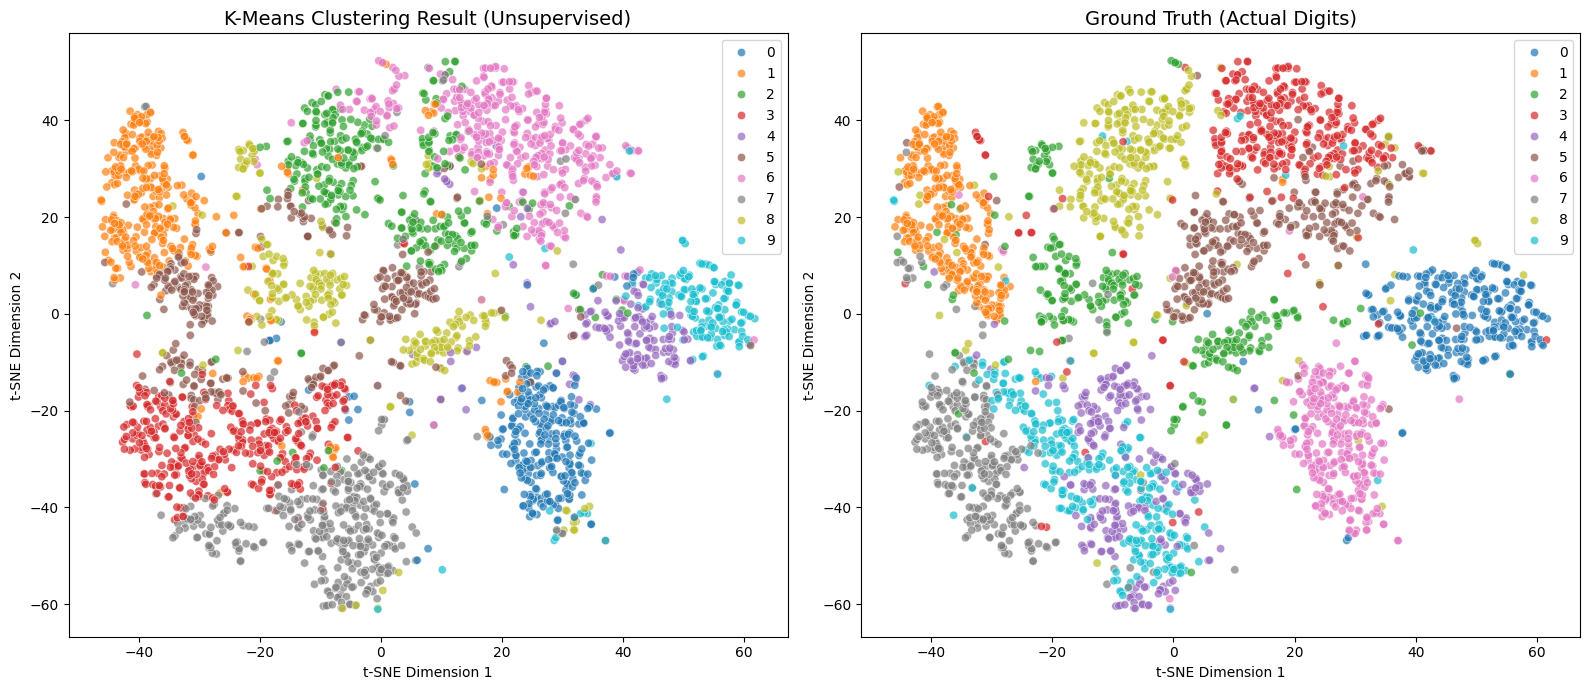

In [11]:
plt.figure(figsize=(16, 7))

# === 左图：K-Means 聚类结果 ===
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans_labels, 
                palette='tab10', legend='full', alpha=0.7)
plt.title('K-Means Clustering Result (Unsupervised)', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# === 右图：真实标签 ===
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_sample, 
                palette='tab10', legend='full', alpha=0.7)
plt.title('Ground Truth (Actual Digits)', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

plt.tight_layout()
plt.show()

## 9. 定量评估：混淆矩阵

看图虽然直观，但我们还是需要计算一下具体的混淆情况。利用混淆矩阵查看 K-Means 最容易把哪两个数字搞混。

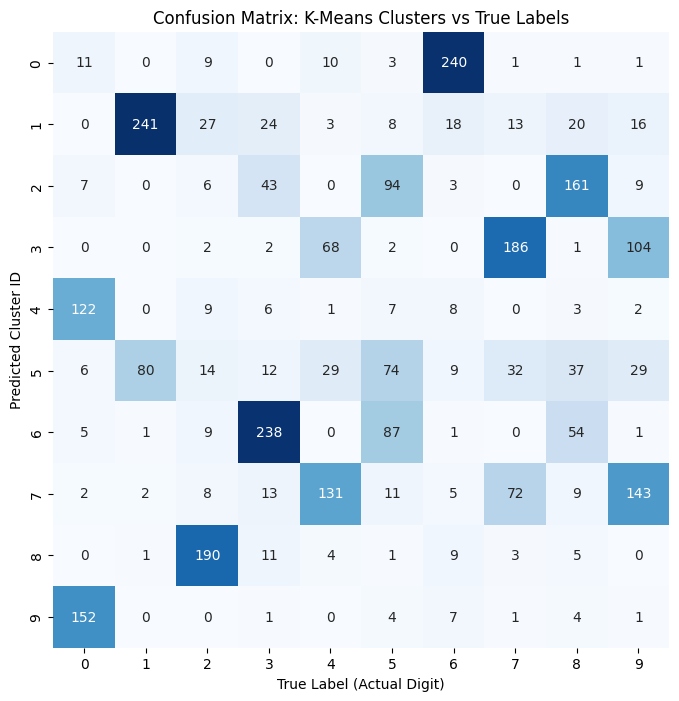

In [12]:
plt.figure(figsize=(10, 8))
mat = confusion_matrix(y_sample, kmeans_labels)

# 绘制热力图
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.xlabel('True Label (Actual Digit)')
plt.ylabel('Predicted Cluster ID')
plt.title('Confusion Matrix: K-Means Clusters vs True Labels')
plt.show()

## 10. 拓展与思考 (Discussion)

###  思考题
1.  **t-SNE 的核心参数 `perplexity` (困惑度)**：
    `perplexity` 大致表示 t-SNE 在降维时考虑“多少个邻居”的影响。
    * 如果将代码中的 `perplexity=30` 改为 **5**，或者是 **100**，生成的图像会发生什么剧烈变化？哪种情况会导致数据看起来像“杂乱的噪点”，哪种情况会让所有岛屿“粘在一起”？

2.  **为什么 t-SNE 分开了，K-Means 却错了？**
    仔细观察 t-SNE 的可视化结果（左图），你可能会发现这样一个现象：**t-SNE 明明把两个数字（比如 4 和 9）分成了两个清晰独立的“岛屿”，但 K-Means 却把这两个岛屿染成了同一种颜色（归为了同一类）。**
    * 这说明数据本身是可分的，还是不可分的？
    * 既然数据可分，为什么 K-Means 还是做不到？这暴露了 K-Means 相比于 t-SNE 的什么短板？

3.  **无监督转有监督的风险**：
    在实验中，我们用“多数投票”给每个簇贴了标签（例如 Cluster 0 里大多是 "7"，所以标记为 "7"）。如果某个簇非常不纯（比如里面有一半是 "3"，一半是 "5"），这种强制贴标签的方法会导致什么后果？在实际应用中，我们应该引入什么指标来监控这种情况？

---

###  解答思路 (Answer Key)

<details>
<summary><strong>点击查看参考答案</strong></summary>

#### 1. 关于 Perplexity 的影响
* **太小 (如 5)**：t-SNE 只关注极小范围的局部结构，导致全局结构丢失，图像会看起来像**破碎的散沙**，很多小簇杂乱无章。
* **太大 (如 100)**：t-SNE 关注过于宽泛的全局结构，会导致不同的簇（岛屿）**相互重叠、粘连**，分不开。
* **结论**：Perplexity 通常在 5-50 之间效果较好，需要根据数据量进行调整。

#### 2. 为什么 K-Means 还是分不开？
* **原因**：这是一个经典的**“算法降维打击”**。t-SNE 是**非线性**流形学习算法，它能理解复杂的扭曲结构；而 K-Means 是基于**欧氏距离**的线性算法，它只能切分出“圆球状”的簇。
* **结论**：可视化结果好（岛屿分开了）说明**数据本身质量很高**（是可分的）。K-Means 聚类错了，说明**K-Means 算法太“笨”了**，它的模型假设（球形簇）无法适应这么复杂的数据分布。

#### 3. 关于“伪标签”的风险
* **后果**：如果簇不纯，强制贴标签会导致大量的**系统性错误**（Systematic Error）。比如机器会自信地把所有的 "5" 都认成 "3"。
* **监控指标**：需要计算 **簇纯度 (Cluster Purity)** 或 **轮廓系数 (Silhouette Score)**。只有当一个簇的纯度极高（比如 >90%）时，我们才能放心地给它打上标签并用于自动化业务。

</details>